# CAPRA on a realistic own-data construction

This notebook follows the own-data tutorial pattern used by Scouter while keeping the CAPRA public API explicit. It constructs an **8,568-cell × 5,025-gene** single-cell matrix with realistic dimensions, uses real Norman gene symbols for the output variables, and uses the bundled **real GenePT embeddings** for perturbation genes. The expression values are simulated only so the tutorial is self-contained; replace the construction cell with your own processed `AnnData` in an applied study.

The split is generated by CAPRA's public `register_evaluation_partitions(split_strategy='auto')` API. The remaining cells show data checks, training, prediction, response plotting, export, and checkpoint reload, with executed outputs retained in this notebook.


In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time
import warnings

started = time.perf_counter()

# Launch from the repository root or demo/. Outputs can be redirected without
# editing this notebook; input data and source files are never overwritten.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
repo_root = next((p for p in candidates if (p / 'capra/frame.py').is_file()), None)
if repo_root is None:
    raise RuntimeError('Launch this notebook from the repository root or demo/.')
sys.path.insert(0, str(repo_root / 'capra'))

import anndata as ad
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from frame import CAPRA, CAPRAData, load_gene_embedding_table

# Scanpy's DEG table assembly emits repeated pandas fragmentation warnings.
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning,
                        message='DataFrame is highly fragmented.*')
torch.set_num_threads(min(4, os.cpu_count() or 1))
timings = {}
print('Python:', platform.python_version(), '| PyTorch:', torch.__version__)
print('Kernel executable:', Path(sys.executable).name)


Python: 3.9.7 | PyTorch: 2.3.0+cu118
Kernel executable: python


In [2]:
demo_name = 'demo_own_data'
condition_key = 'condition'       # input adata.obs column
perturbation_key = 'perturbation'  # input adata.obs column
seed = 24
max_epochs, n_pred, val_n_pred, num_workers = 1, 16, 16, 0
accelerator = 'gpu'
if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU is required for this demo.')
output_base = Path(os.environ.get('CAPRA_DEMO_OUTPUT_ROOT', str(repo_root / 'demo/outputs'))).resolve()
output_dir = output_base / demo_name
print('GPU:', torch.cuda.get_device_name(0))
print('Selected obs keys:', condition_key, perturbation_key)


GPU: NVIDIA GeForce RTX 3090
Selected obs keys: condition perturbation


## 1. Construct a realistic own-data matrix

The construction below matches the full bundled Norman dimensions (`8,568 × 5,025`) without requiring the full expression matrix as an external download. Perturbation targets are selected from the bundled GenePT index.


In [3]:
stage_started = time.perf_counter()
import scanpy as sc
from scipy import sparse

rng = np.random.default_rng(seed)
adata_path = repo_root / 'demo/data/norman_example.h5ad'
embedding_path = repo_root / 'demo/data/norman_example_genept_embeddings.pkl'
for path in (adata_path, embedding_path):
    if not path.is_file():
        raise FileNotFoundError(path)

# Use the bundled measured file only to obtain the real Norman gene symbols and
# dimensions; the expression values below are generated for this self-contained
# own-data tutorial.
reference = ad.read_h5ad(adata_path, backed='r')
genes = reference.var_names.astype(str).tolist()
assert reference.shape == (8568, 5025), reference.shape
reference.file.close()

# These are real GenePT vectors from the bundled table. CAPRA will align them
# to all output genes and use zeros only for output genes absent from GenePT.
all_embeddings = load_gene_embedding_table(embedding_path, add_control=False)
perturbation_genes = [
    'CEBPB', 'FOS', 'GATA1', 'IRF1', 'JUN', 'MYC', 'STAT1', 'CEBPA',
    'KLF1', 'MAP2K6', 'SET', 'TGFBR2', 'FOXA1', 'NFE2', 'SMARCA2',
]
assert set(perturbation_genes).issubset(all_embeddings.index)
embedding_table = all_embeddings.copy()
embedding_table.loc['ctrl'] = np.zeros(embedding_table.shape[1], dtype=np.float32)

# Include singles and doubles so the public automatic split reports seen-gene
# combination subgroups. All perturbation genes come from the real GenePT index.
double_conditions = [
    'CEBPB+FOS', 'GATA1+IRF1', 'JUN+MYC', 'STAT1+CEBPA',
    'KLF1+MAP2K6', 'SET+TGFBR2', 'FOXA1+NFE2', 'SMARCA2+CEBPB',
]
conditions = ['control'] + perturbation_genes + double_conditions
n_cells = {'control': 432}
remaining = 8568 - n_cells['control']
base, extra = divmod(remaining, len(conditions) - 1)
for index, condition in enumerate(conditions[1:]):
    n_cells[condition] = base + int(index < extra)
assert sum(n_cells.values()) == 8568

# Gamma-Poisson counts create variable library sizes and overdispersion while
# preserving the real single-cell matrix dimensions.
gene_abundance = rng.lognormal(mean=-2.0, sigma=0.85, size=len(genes))
gene_to_position = {gene: index for index, gene in enumerate(genes)}
blocks, labels = [], []
for condition in conditions:
    fold = np.ones(len(genes), dtype=np.float64)
    if condition != 'control':
        for gene in condition.split('+'):
            position = gene_to_position[gene]
            fold[position] *= 0.25
            for offset, multiplier in ((32, 1.8), (96, 0.65), (160, 1.35)):
                indices = (position + np.arange(12) + offset) % len(genes)
                fold[indices] *= multiplier
    library_factor = rng.lognormal(mean=0.0, sigma=0.45, size=(n_cells[condition], 1))
    mean_counts = gene_abundance[None, :] * fold[None, :] * library_factor
    overdispersed_rate = rng.gamma(shape=2.0, scale=mean_counts / 2.0)
    counts = rng.poisson(overdispersed_rate).astype(np.float32)
    blocks.append(sparse.csr_matrix(counts))
    labels.extend([condition] * n_cells[condition])

obs = pd.DataFrame(
    {condition_key: labels, perturbation_key: labels},
    index=[f'own_cell_{i:05d}' for i in range(len(labels))],
)
adata = ad.AnnData(
    X=sparse.vstack(blocks, format='csr'),
    obs=obs,
    var=pd.DataFrame(index=genes),
)
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.uns['demo_provenance'] = {
    'expression': 'simulated gamma-Poisson counts with bundled Norman dimensions',
    'gene_embeddings': 'bundled GenePT table indexed by gene symbol',
}
assert adata.shape == (8568, 5025)
print('Own-data AnnData:', adata.shape, 'sparse:', sparse.issparse(adata.X))
print('GenePT table:', embedding_table.shape, 'perturbation genes:', len(perturbation_genes))
print('Condition groups:', len(conditions) - 1, 'control cells:', n_cells['control'])
display(adata.obs[ [condition_key, perturbation_key] ].head())
timings['input_construction_seconds'] = time.perf_counter() - stage_started


Own-data AnnData: (8568, 5025) sparse: True
GenePT table: (4995, 3072) perturbation genes: 15
Condition groups: 23 control cells: 432


,condition,perturbation
own_cell_00000,control,control
own_cell_00001,control,control
own_cell_00002,control,control
own_cell_00003,control,control
own_cell_00004,control,control


## 2. Prepare data with the CAPRA API

`CAPRAData` canonicalizes labels, creates condition-level train/validation/test partitions, estimates train/validation DEG references, and builds the control-relative response anchors.


## 3. Train CAPRA


In [4]:
stage_started = time.perf_counter()
capra_data = CAPRAData(
    adata=adata, embedding_table=embedding_table, study_name=demo_name,
    condition_key=condition_key, perturbation_key=perturbation_key,
)
capra_data.harmonize_perturbation_metadata(copy=False)
capra_data.register_evaluation_partitions(split_strategy='auto', random_state=1)
capra_data.estimate_trainval_deg_reference(method='t-test')
assert not (set(capra_data.deg_frames_by_condition) & set(capra_data.splits['test']))
capra_data.build_control_relative_training_state(
    topk_deg=100, knn_topk=5, knn_temperature=12.0,
)
print('Train/val/test conditions:', {key: len(value) for key, value in capra_data.splits.items()})
print('Training response bank:', len(capra_data.assets.train_single_delta))
if capra_data.subgroup and 'test_subgroup' in capra_data.subgroup:
    print('Automatic test subgroups:', {key: len(value) for key, value in capra_data.subgroup['test_subgroup'].items()})
timings['data_preparation_seconds'] = time.perf_counter() - stage_started


Train/val/test conditions: {'train': 16, 'val': 1, 'test': 6}
Training response bank: 11
Automatic test subgroups: {'combo_seen0': 0, 'combo_seen1': 3, 'combo_seen2': 0, 'unseen_single': 3}


## 4. Predict held-out perturbations


In [5]:
stage_started = time.perf_counter()
model = CAPRA(capra_data)
model.fit_capra_response_operator(
    output_dir=output_dir / 'results', run_name=f'{demo_name}_seed{seed}',
    n_epochs=max_epochs, min_epochs=1, seed=seed,
    accelerator=accelerator, precision='16-mixed', num_workers=num_workers,
    pin_memory=True, val_n_pred=val_n_pred,
)
timings['training_seconds'] = time.perf_counter() - stage_started


CAPRA training | epoch 1/1 | train_loss=1.5964 | val_unseen_loss=0.4911 | monitor=0.7086 | patience=0/10


## 5. Inspect the predicted response

The existing response scatter plot is retained. The table reports the ten strongest measured control-relative responses for one held-out condition.


In [6]:
stage_started = time.perf_counter()
test_conditions = list(capra_data.splits['test'])[:3]
predictions = model.generate_counterfactual_profiles(pert_list=test_conditions, n_pred=n_pred)
timings['prediction_seconds'] = time.perf_counter() - stage_started
print('Predicted API-held-out conditions:', test_conditions)
for condition, matrix in predictions.items():
    print(condition, matrix.shape)


Predicted API-held-out conditions: ['FOXA1', 'FOXA1+NFE2', 'GATA1+IRF1']
FOXA1 (16, 5025)
FOXA1+NFE2 (16, 5025)
GATA1+IRF1 (16, 5025)


## 6. Save predictions and run metadata


Held-out condition: FOXA1
All-gene response Pearson r: 0.1093


,observed_mean,predicted_mean,observed_delta,predicted_delta
gene,,,,
RGS11,1.1077,1.2413,0.3453,0.4789
NME3,0.7711,0.2663,0.3301,-0.1747
COL4A5,1.8850,1.5671,0.3154,-0.0025
ZSWIM4,1.2906,1.4449,0.3076,0.4619
SCT,0.3550,0.3831,-0.2998,-0.2717
PRRG4,0.7252,0.0717,0.2894,-0.3641
P2RY2,1.2087,1.1781,0.2737,0.2432
FAM53C,1.2379,0.8519,0.2670,-0.1190
MYO6,1.0487,0.6162,0.2647,-0.1678


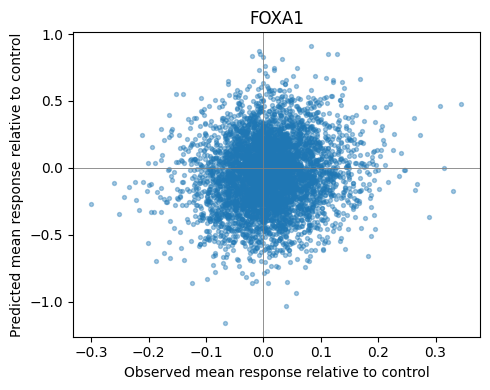

In [7]:
# Inspect the measured and predicted mean responses for one held-out condition.
from IPython.display import display
import matplotlib.pyplot as plt
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

condition = test_conditions[0]
canonical_labels = capra_data.adata.obs['perturbation'].astype(str)
control_mean = np.asarray(capra_data.adata[canonical_labels == 'control'].X.mean(axis=0)).ravel()
observed_mean = np.asarray(capra_data.adata[canonical_labels == condition].X.mean(axis=0)).ravel()
predicted_mean = predictions[condition].mean(axis=0)
response_table = pd.DataFrame({
    'observed_mean': observed_mean,
    'predicted_mean': predicted_mean,
    'observed_delta': observed_mean - control_mean,
    'predicted_delta': predicted_mean - control_mean,
}, index=capra_data.adata.var_names)
response_table.index.name = 'gene'
strongest = response_table['observed_delta'].abs().nlargest(10).index
pearson = np.corrcoef(response_table['observed_delta'], response_table['predicted_delta'])[0, 1]
print('Held-out condition:', condition)
print('All-gene response Pearson r:', round(float(pearson), 4))
display(response_table.loc[strongest].round(4))
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(response_table['observed_delta'], response_table['predicted_delta'], s=8, alpha=0.4)
ax.axhline(0, color='grey', linewidth=0.6)
ax.axvline(0, color='grey', linewidth=0.6)
ax.set(xlabel='Observed mean response relative to control',
       ylabel='Predicted mean response relative to control', title=condition)
fig.tight_layout()
plt.show()


## 7. Reload the checkpoint and verify predictions


In [8]:
stage_started = time.perf_counter()
blocks = []
for condition, matrix in predictions.items():
    assert matrix.shape == (n_pred, capra_data.adata.n_vars)
    assert np.isfinite(matrix).all(), f'Non-finite prediction: {condition}'
    obs = pd.DataFrame(
        {'condition': condition, 'perturbation': condition, 'Expcategory': 'imputed'},
        index=[f'{condition}_pred_{i}' for i in range(len(matrix))],
    )
    blocks.append(ad.AnnData(
        X=matrix.astype(np.float32, copy=False), obs=obs,
        var=pd.DataFrame(index=capra_data.adata.var_names.copy()),
    ))
prediction_adata = ad.concat(blocks, merge='same')
assert prediction_adata.var_names.equals(capra_data.adata.var_names)
prediction_adata.uns['demo'] = {'name': demo_name, 'seed': seed}
output_dir.mkdir(parents=True, exist_ok=True)
prediction_path = output_dir / 'predictions.h5ad'
prediction_adata.write_h5ad(prediction_path)
timings['export_seconds'] = time.perf_counter() - stage_started
summary = {
    'demo': demo_name, 'seed': seed,
    'input_shape': list(capra_data.adata.shape),
    'split_conditions': {key: len(value) for key, value in capra_data.splits.items()},
    'predicted_conditions': list(predictions),
    'prediction_shape': list(prediction_adata.shape),
    'n_pred_per_condition': n_pred,
    'best_checkpoint': str(Path(model.fitted['metrics']['best_checkpoint']).relative_to(output_dir)),
    'epochs_completed': model.fitted['metrics']['epochs_completed'],
    'timings': timings,
    'total_seconds': time.perf_counter() - started,
    'environment': {
        'python': platform.python_version(), 'platform': platform.platform(),
        'torch': torch.__version__, 'numpy': np.__version__, 'pandas': pd.__version__,
        'device': model.fitted['metrics']['runtime']['device'],
        'torch_threads': torch.get_num_threads(),
    },
    'training': {
        'max_epochs': max_epochs, 'val_n_pred': val_n_pred,
        'num_workers': num_workers, 'batch_size': 192,
    },
}
(output_dir / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved predictions:', prediction_path.relative_to(repo_root)
      if prediction_path.is_relative_to(repo_root) else prediction_path)
print('Prediction shape:', prediction_adata.shape)
print('Timings (seconds):', {k: round(v, 2) for k, v in timings.items()})
print('Total run seconds:', round(summary['total_seconds'], 2))


Saved predictions: /home/fzc/projects/202604_CAPRA/tmp/githubload_review/fresh_20261002/demo_own_data/predictions.h5ad
Prediction shape: (48, 5025)
Timings (seconds): {'input_construction_seconds': 5.86, 'data_preparation_seconds': 6.22, 'training_seconds': 10.83, 'prediction_seconds': 0.16, 'export_seconds': 0.03}
Total run seconds: 25.98


## 7. Reload the checkpoint and verify predictions


In [9]:
# Reload with the same data assets; no fitting occurs in this cell.
stage_started = time.perf_counter()
checkpoint = model.fitted['metrics']['best_checkpoint']
loaded = CAPRA(capra_data)
loaded.load_capra_response_operator(checkpoint, accelerator=accelerator, output_dir=output_dir / 'results')
first_condition = test_conditions[0]
reloaded = loaded.generate_counterfactual_profiles(
    pert_list=[first_condition], n_pred=n_pred, sampling_state=seed,
)[first_condition]
np.testing.assert_allclose(reloaded, predictions[first_condition], rtol=1e-5, atol=1e-5)
summary['checkpoint_reload_verified'] = True
summary['timings']['reload_seconds'] = time.perf_counter() - stage_started
summary['total_seconds'] = time.perf_counter() - started
(output_dir / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Checkpoint reload verified:', first_condition)
print('Completed:', demo_name)
print('Prediction file:', prediction_path.relative_to(repo_root)
      if prediction_path.is_relative_to(repo_root) else prediction_path)
print('Verified prediction shape:', prediction_adata.shape)
print('End-to-end seconds:', round(summary['total_seconds'], 2))


Checkpoint reload verified: FOXA1
Completed: demo_own_data
Prediction file: /home/fzc/projects/202604_CAPRA/tmp/githubload_review/fresh_20261002/demo_own_data/predictions.h5ad
Verified prediction shape: (48, 5025)
End-to-end seconds: 26.65
